# $J_{ij}$ check: carrier π-time in, predicted coupling out

One job. Given a measured **carrier** π-time, predict $J_{ij}$ and the
$|01\rangle\to|10\rangle$ π-time, and compare to what the calibration reports.

Pure numpy — no htdse, no h5repl, no solver. Every step below is one line of algebra.

Every formula is written **fully expanded**: no shorthand symbol stands in for a
combination of the input arrays. If a number comes out wrong, it is wrong at a line
where you can see which array it came from.

## The definitions, in full

### Inputs

| symbol | meaning | source |
|---|---|---|
| $t_{\pi,i}^{\rm carrier}$ | carrier π-time of ion $i$ | measured |
| $\nu_m$ | frequency of mode $m$ | `radial_modes` (MHz) |
| $\eta_m$ | Lamb–Dicke parameter of mode $m$ | `lamb_dicke_parameters` |
| $b_{m,i}$ | participation of ion $i$ in mode $m$ | `participation_factors[m][i]` |
| $\Delta$ | detuning from a chosen reference mode | set by you |
| $i,\;j$ | the two ion indices | set by you |

**Units.** Everything internal is $\mathrm{rad}/\mu\mathrm{s}$ and $\mu\mathrm{s}$:

$$1\ \mathrm{MHz} \;\longleftrightarrow\; 2\pi\ \mathrm{rad}/\mu\mathrm{s},
\qquad 1\ \mathrm{kHz} \;\longleftrightarrow\; 2\pi\times10^{-3}\ \mathrm{rad}/\mu\mathrm{s}$$

---

### 1. Carrier Rabi frequency

The single-qubit carrier is **defined** with the $\tfrac12$ in the Hamiltonian:

$$H_{\rm carrier} = \frac{\Omega}{2}\,\sigma_x
\qquad\Longrightarrow\qquad
P_{|1\rangle}(t) = \sin^2\!\Big(\frac{\Omega t}{2}\Big)
\qquad\Longrightarrow\qquad
\boxed{\;\Omega_i = \frac{\pi}{t_{\pi,i}^{\rm carrier}}\;}$$

So $\Omega$ is the **energy gap**, not the Hamiltonian coefficient. This matches
h5repl's `rabi_flop(x, amp, omega, offset) = offset + amp·sin(ωx/2)²`, whose docstring
states `pi_time = π/omega`. Same convention, verified in source.

---

### 2. Lamb–Dicke coupling of one ion to one mode

`participation_factors` has **rows = modes, columns = ions**, so

$$\eta_{i,m} = \eta_m\, b_{m,i}$$

This is the last time $\eta_{i,m}$ appears as a symbol. Everywhere below it is written
out as $\eta_m b_{m,i}$.

---

### 3. Detuning

One bichromatic beat $\mu$ drives the whole chain, so the detuning depends on the mode
but not on the ion:

$$\mu = \nu_{\rm ref} + \Delta,
\qquad\boxed{\;\delta_m = \mu - \nu_m = \nu_{\rm ref} + \Delta - \nu_m\;}$$

---

### 4. Accumulated phase (exact, constant pulse)

$$\boxed{\;\Theta(t) \;=\;
\sum_m \frac{b_{m,i}\,b_{m,j}\;\eta_m^{2}\;\Omega_i\,\Omega_j}{2\,\delta_m}
\left(t \;-\; \frac{\sin \delta_m t}{\delta_m}\right)\;}$$

Its derivative,

$$\frac{d\Theta}{dt} \;=\; \sum_m
\frac{b_{m,i}\,b_{m,j}\;\eta_m^{2}\;\Omega_i\,\Omega_j}{2\,\delta_m}
\Big(1 - \cos \delta_m t\Big),$$

vanishes at $\delta_m t = 2\pi k$ — hence the staircase, with flat steps every
$2\pi/\delta_m$.

---

### 5. The coupling $J$

Define $J$ as the long-time slope of $\Theta$, i.e. drop the oscillatory term
($|\delta_m|t \gg 1$):

$$\boxed{\;J_{ij} \;=\; \sum_m
\frac{b_{m,i}\,b_{m,j}\;\eta_m^{2}\;\Omega_i\,\Omega_j}{2\,\delta_m}\;}
\qquad\text{so that}\qquad \Theta \to J t,
\qquad H_{\rm eff} = J\,\sigma\sigma$$

Substituting $\Omega_i = \pi/t_{\pi,i}^{\rm carrier}$ and
$\delta_m = \nu_{\rm ref}+\Delta-\nu_m$ leaves nothing but measured numbers and file
entries:

$$J_{ij} \;=\; \frac{\pi^{2}}
{2\;t_{\pi,i}^{\rm carrier}\;t_{\pi,j}^{\rm carrier}}
\;\sum_m\; \frac{b_{m,i}\,b_{m,j}\;\eta_m^{2}}
{\nu_{\rm ref} + \Delta - \nu_m}$$

**Exponents, because they set how errors propagate.** $\eta_m$ enters **squared**; each
ion's $b_{m,i}$ enters **once**; each carrier π-time enters **squared** (through
$\Omega^2$). A $\sqrt2$ error in $\eta_m$, or in $\Omega$, or in *both* participation
factors together, each give a factor 2 in $J$.

**Signs.** $b_{m,i}b_{m,j}$ is signed, and $\delta_m$ flips sign across each mode, so
terms partially cancel. The per-mode table below prints each contribution separately —
look at it before trusting the total.

**$J$ is a Hamiltonian coefficient, not a gap** — unlike $\Omega$. That asymmetry is the
origin of every factor of 2 in this problem.

---

### 6. π-times and the gate angle

$\sigma\sigma$ connects $|01\rangle \leftrightarrow |10\rangle$ with matrix element $J$,
so it is a two-level Rabi problem with gap $\Delta E = 2J$:

$$P_{|10\rangle}(t) = \sin^2\Theta(t),
\qquad\boxed{\;t_\pi^{01\to10} = \frac{\pi}{2J}\;}$$

| condition | $\Theta$ | meaning |
|---|---|---|
| $\Theta = \pi/4$ | $Jt=\pi/4$ | maximally entangling (Bell) |
| $\Theta = \pi/2$ | $Jt=\pi/2$ | full $01\to10$ transfer |

Both π-times obey the same rule $t_\pi = \pi/\Delta E$ — carrier $\Delta E = \Omega$,
MS $\Delta E = 2J$. Use the gap and you cannot be off by 2.

---

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

MHZ = 2 * np.pi          # 1 MHz -> rad/us
KHZ = 2 * np.pi * 1e-3   # 1 kHz -> rad/us

GOLD_5  = r"ion5-goldparams.json"
GOLD_13 = r"062726_goldparams_13ions.json"


def load_goldparams(path):
    """nu_MHz (n_modes,), eta_m (n_modes,), b (n_modes, n_ions)."""
    with open(path) as fh:
        d = json.load(fh)
    nu_MHz = np.asarray(d["radial_modes"], dtype=float)
    eta_m = np.asarray(d["lamb_dicke_parameters"], dtype=float)
    b = np.asarray(d["participation_factors"], dtype=float)
    if b.shape[0] != nu_MHz.size:
        raise ValueError(f"{b.shape[0]} participation rows vs {nu_MHz.size} modes -- "
                         "is the file stored (ion, mode)?")
    return nu_MHz, eta_m, b

## calculation

In [18]:
def predict_jij(nu_MHz, eta_m, b, ions, pi_time_us, delta_khz, ref_mode):
    """Sections 1-7, in order. Returns a dict.

    ions       : (i, j) COLUMN indices of participation_factors
    pi_time_us : carrier pi-time, scalar or [t_i, t_j]
    delta_khz  : Delta = mu - nu[ref_mode], in kHz
    """
    i, j = ions

    # sec 1 :  Omega_i = pi / t_pi_i
    Om = np.pi / np.broadcast_to(np.asarray(pi_time_us, float), (2,))

    # sec 3 :  mu = nu_ref + Delta ;  delta_m = mu - nu_m
    nu = MHZ * nu_MHz
    mu = nu[ref_mode] + delta_khz * KHZ
    delta = mu - nu

    # sec 5 :  J_m = b_mi b_mj eta_m^2 Om_i Om_j / (2 delta_m)
    J_per_mode = b[:, i] * b[:, j] * eta_m ** 2 * Om[0] * Om[1] / (2 * delta)
    J = J_per_mode.sum()

    return dict(
        Om=Om, mu=mu, delta=delta,
        b_i=b[:, i], b_j=b[:, j], eta_m=eta_m,
        J_per_mode=J_per_mode,
        J=J,
        t_pi_ms=np.pi / (2 * abs(J)),              # sec 6 :  t_pi = pi / 2J
        J_hz=J / (2 * np.pi) * 1e6,                # J as a frequency, Hz
        reported_hz=2 * J / (2 * np.pi) * 1e6,     # sec 7 :  omega_fit/2pi = 2J/2pi
    )


def theta_of_t(t, r):
    """sec 4, exact:  Theta(t) = sum_m J_m (t - sin(delta_m t)/delta_m)."""
    t = np.atleast_1d(np.asarray(t, float))[:, None]
    return np.sum(r["J_per_mode"] * (t - np.sin(r["delta"] * t) / r["delta"]), axis=-1)


def report(r, nu_MHz, ions, pi_time_us, delta_khz, ref_mode):
    i, j = ions
    print(f"ions {ions}   carrier t_pi = {pi_time_us} us   "
          f"Delta = {delta_khz:g} kHz from mode {ref_mode}")
    print(f"Omega = {r['Om']} rad/us = {r['Om']/KHZ} kHz")
    print(f"mu    = {r['mu']/MHZ:.6f} MHz\n")
    print(f"{'m':>2} {'nu (MHz)':>10} {'delta(kHz)':>11} {f'b[m,{i}]':>10} {f'b[m,{j}]':>10} "
          f"{'eta_m':>8} {'J_m (kHz)':>11} {'2pi/d (us)':>11}")
    for m in range(nu_MHz.size):
        print(f"{m:>2} {nu_MHz[m]:>10.6f} {r['delta'][m]/KHZ:>11.2f} "
              f"{r['b_i'][m]:>10.5f} {r['b_j'][m]:>10.5f} {r['eta_m'][m]:>8.5f} "
              f"{r['J_per_mode'][m]/KHZ:>11.5f} {2*np.pi/abs(r['delta'][m]):>11.2f}")
    print(f"{'':>2} {'':>10} {'':>11} {'':>10} {'':>10} {'sum:':>8} "
          f"{r['J']/KHZ:>11.5f}")
    print(f"\nJ                       = {r['J']:.6e} rad/us  =  {r['J']/KHZ:.4f} kHz")
    print(f"t_pi(01->10) = pi/2J    = {r['t_pi_ms']:.2f} us")
    print(f"\nJ/2pi                   = {r['J_hz']:.1f} Hz   <- J as a frequency")
    print(f"omega_fit/2pi = 2J/2pi  = {r['reported_hz']:.1f} Hz   <- what the fit reports")

In [17]:
GOLD       = GOLD_13
IONS       = (6, 7)
PI_TIME_US = 2.98 * 1.8        # carrier pi-time; scalar or [t_i, t_j]
REF_MODE   = 0
DELTA_KHZ  = -10.0

nu_MHz, eta_m, b = load_goldparams(GOLD)
r = predict_jij(nu_MHz, eta_m, b, IONS, PI_TIME_US, DELTA_KHZ, REF_MODE)
report(r, nu_MHz, IONS, PI_TIME_US, DELTA_KHZ, REF_MODE)

ions (6, 7)   carrier t_pi = 5.364 us   Delta = -10 kHz from mode 0
Omega = [0.58568096 0.58568096] rad/us = [93.21401939 93.21401939] kHz
mu    = 2200064.990898 MHz

 m   nu (MHz)  delta(kHz)     b[m,6]     b[m,7]    eta_m   J_m (kHz)  2pi/d (us)
 0 2200065.000898      -10.00    0.50473   -0.45955  0.12583     1.59545      100.00
 1 2219690.702948 -19625712.05    0.00000    0.32002  0.12548    -0.00000        0.00
 2 2241441.579420 -41376588.52    0.41344   -0.19555  0.12506     0.00000        0.00
 3 2264367.162822 -64302171.92    0.00000    0.38127  0.12461    -0.00000        0.00
 4 2287423.380886 -87358389.99    0.37577   -0.00270  0.12415     0.00000        0.00
 5 2310500.593835 -110435602.94    0.00000   -0.35650  0.12370     0.00000        0.00
 6 2333154.844015 -133089853.12    0.35437    0.14134  0.12326    -0.00000        0.00
 7 2354779.958600 -154714967.70    0.00000    0.28598  0.12284    -0.00000        0.00
 8 2375017.672346 -174952681.45   -0.34117   -0.24218  0.12245

## All pairs at once

$$J_{ij} \;=\; \frac{\pi^{2}}{2\,t_{\pi,i}\,t_{\pi,j}}
\sum_m \frac{b_{m,i}\,b_{m,j}\,\eta_m^{2}}{\nu_{\rm ref}+\Delta-\nu_m}$$

for every pair at the current settings. The **pattern** across pairs is fixed by
$b_{m,i}$ and $\eta_m$ alone — a global prefactor error scales the whole matrix
uniformly, while wrong participation factors change its shape. Two different diagnoses
from one plot.

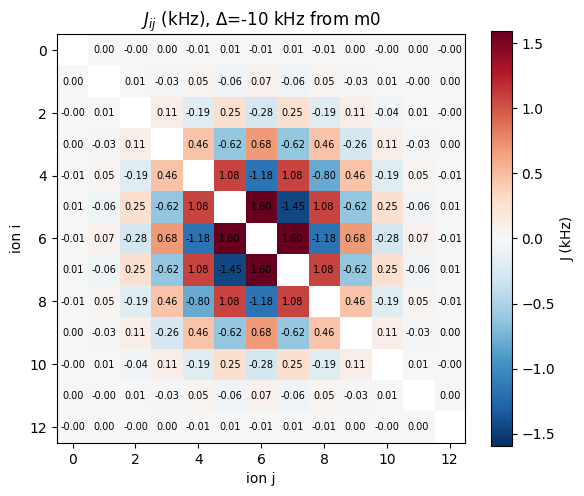

In [19]:
n_ions = b.shape[1]
Jmat = np.full((n_ions, n_ions), np.nan)
for i in range(n_ions):
    for j in range(n_ions):
        if i != j:
            Jmat[i, j] = predict_jij(nu_MHz, eta_m, b, (i, j), PI_TIME_US,
                                     DELTA_KHZ, REF_MODE)["J"] / KHZ

fig, ax = plt.subplots(figsize=(6, 5))
v = np.nanmax(np.abs(Jmat))
im = ax.imshow(Jmat, cmap="RdBu_r", vmin=-v, vmax=v)
for i in range(n_ions):
    for j in range(n_ions):
        if i != j:
            ax.text(j, i, f"{Jmat[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_xlabel("ion j"); ax.set_ylabel("ion i")
ax.set_title(f"$J_{{ij}}$ (kHz), $\\Delta$={DELTA_KHZ:g} kHz from m{REF_MODE}")
plt.colorbar(im, label="J (kHz)"); plt.tight_layout(); plt.show()